In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_selection import SequentialFeatureSelector

import statsmodels.api as sm

reglog = LogisticRegression()

df = pd.read_csv('Dados completos.csv',sep=';')
df = df.drop(columns=['Unnamed: 7','Unnamed: 8'])

colunas_texto = df.select_dtypes(include=['object', 'string']).columns

for coluna in colunas_texto:
    df[coluna] = df[coluna].str.replace('.', '', regex=False).astype(float)

In [28]:
display(df.describe())

,Média,Variância,Máximo,Energia,Skewness,Kurtosis,Label
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000
mean,-8.438037e+15,1.173357e+16,7.841814e+15,1.027042e+16,-6.786316e+15,9.540475e+15,0.503000
std,9.539351e+15,1.153940e+16,1.103329e+16,1.039960e+16,9.990352e+15,1.194975e+16,0.500241
min,-7.864163e+16,2.480999e+12,2.936875e+06,6.999357e+12,-3.899531e+16,4.244220e+13,0.000000
25%,-9.399621e+15,2.630805e+15,2.866232e+15,5.575667e+15,-1.305271e+16,4.518518e+15,0.000000
50%,-7.989082e+15,4.768309e+15,3.392643e+15,8.587714e+15,-2.791614e+15,6.874559e+15,1.000000
75%,-5.870395e+15,1.908988e+16,4.171801e+15,1.268923e+16,-3.051710e+14,9.713771e+15,1.000000
max,-9.296770e+12,7.123235e+16,4.724941e+16,6.686140e+16,1.797384e+16,7.895620e+16,1.000000


In [29]:
display(df.corr())

,Média,Variância,Máximo,Energia,Skewness,Kurtosis,Label
Média,1.000000,-0.002692,0.022080,-0.021433,-0.055481,0.019382,-0.072869
Variância,-0.002692,1.000000,-0.009457,0.013241,0.004978,0.039454,0.011130
Máximo,0.022080,-0.009457,1.000000,0.008743,0.001398,-0.021452,0.004316
Energia,-0.021433,0.013241,0.008743,1.000000,0.024207,0.020056,0.047274
Skewness,-0.055481,0.004978,0.001398,0.024207,1.000000,0.001587,0.511130
Kurtosis,0.019382,0.039454,-0.021452,0.020056,0.001587,1.000000,0.027945
Label,-0.072869,0.011130,0.004316,0.047274,0.511130,0.027945,1.000000


0.64


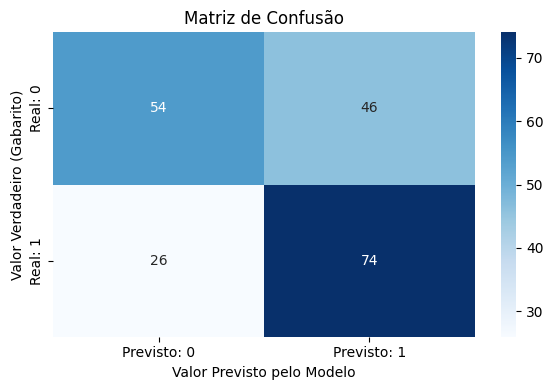

In [30]:
X = df.drop(columns='Label')
Y = df['Label']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

reglog.fit(X_train,Y_train)

Y_predict = reglog.predict(X_test)

print(accuracy_score(Y_test,Y_predict))

matriz_c = confusion_matrix(Y_test,Y_predict)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: 0', 'Previsto: 1'], 
            yticklabels=['Real: 0', 'Real: 1'])

plt.title('Matriz de Confusão')
plt.ylabel('Valor Verdadeiro (Gabarito)')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()

In [31]:
X_train = sm.add_constant(X_train)

modelo_sm = sm.Logit(Y_train, X_train).fit()

print(modelo_sm.summary())

Optimization terminated successfully.
         Current function value: 0.530505
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  Label   No. Observations:                  800
Model:                          Logit   Df Residuals:                      793
Method:                           MLE   Df Model:                            6
Date:                Fri, 04 Sep 2026   Pseudo R-squ.:                  0.2346
Time:                        10:16:38   Log-Likelihood:                -424.40
converged:                       True   LL-Null:                       -554.50
Covariance Type:            nonrobust   LLR p-value:                 2.730e-53
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5257      0.200      2.634      0.008       0.135       0.917
Média      -1.956e-17    1.1e

In [32]:
#feature selection

In [33]:
sfs_forward = SequentialFeatureSelector(
    estimator=reglog,
    n_features_to_select='auto',
    tol=0.01,
    direction='forward', 
    cv=5 # Validação cruzada (5-folds)
)
X_forward = sfs_forward.fit_transform(X_train, Y_train)
print("Forward:", sfs_forward.get_support(indices=False))

display(X_train.head(5))


Forward: [False False False False False  True False]


,const,Média,Variância,Máximo,Energia,Skewness,Kurtosis
687,1.0,-8.368267e+15,1.110799e+15,2.736382e+15,4.513120e+16,-2.897644e+14,1.227787e+16
500,1.0,-7.833373e+15,3.122694e+15,3.208507e+15,1.216946e+16,-6.804313e+15,3.245526e+16
332,1.0,-7.928808e+15,2.057815e+15,2.929013e+15,8.105243e+15,-7.509915e+15,6.013671e+16
979,1.0,-9.290636e+15,1.504583e+15,2.962393e+16,6.080414e+15,-2.145949e+16,8.980622e+15
817,1.0,-7.981143e+15,1.304426e+16,3.773473e+15,5.228972e+15,-2.481777e+14,1.265442e+15


Optimization terminated successfully.
         Current function value: 0.535347
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  Label   No. Observations:                  800
Model:                          Logit   Df Residuals:                      798
Method:                           MLE   Df Model:                            1
Date:                Fri, 04 Sep 2026   Pseudo R-squ.:                  0.2276
Time:                        10:16:39   Log-Likelihood:                -428.28
converged:                       True   LL-Null:                       -554.50
Covariance Type:            nonrobust   LLR p-value:                 7.648e-57
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8948      0.100      8.961      0.000       0.699       1.090
Skewness    1.529e-16   1.27e

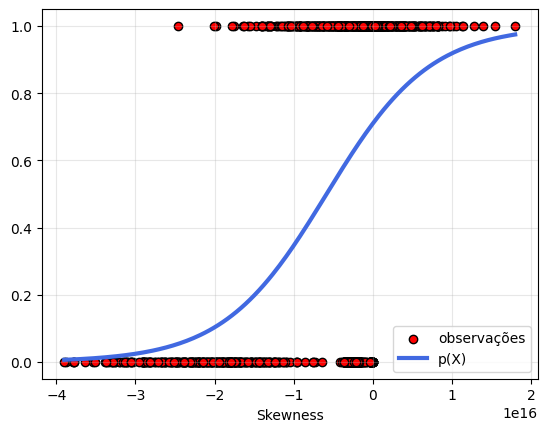

In [34]:
X_train = X_train[['const','Skewness']]
X_train = sm.add_constant(X_train)

modelo_sm = sm.Logit(Y_train, X_train).fit()

print(modelo_sm.summary())

b0 = modelo_sm.params.iloc[0]
b1 = modelo_sm.params.iloc[1]

def p(x,b0,b1):
    return 1/(1+np.exp(-(b0+b1*x)))

x = np.linspace(df['Skewness'].min(),df['Skewness'].max(),200)
px = p(x,b0,b1)

plt.figure()
plt.grid(alpha=0.3)
plt.scatter(df['Skewness'],df['Label'],color='red',label='observações',edgecolors='black')
plt.plot(x,px,label='p(X)',color='royalblue',linewidth=3)
plt.xlabel('Skewness')
plt.legend()
plt.show()

,index,Skewness
0,0,-1.530590e+15
1,1,-1.704711e+15
2,2,6.256202e+14
3,3,5.076175e+15
4,4,7.629875e+15


0    1
1    1
2    1
3    1
4    1
Name: Label, dtype: int64

Label
1    503
0    497
Name: count, dtype: int64

0.6766666666666666


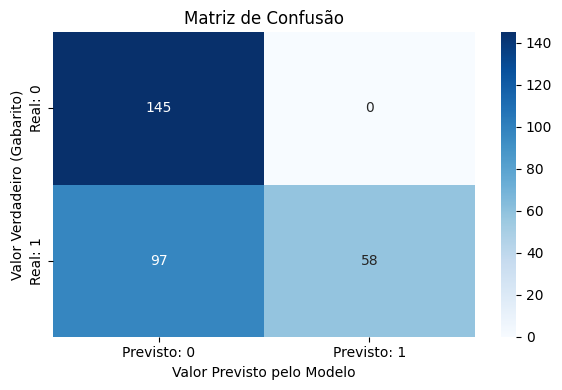

In [39]:
X = df['Skewness'].reset_index()
Y = df['Label']

display(X.head(5))

display(Y.head(5))

display(Y.value_counts())

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3,random_state=0)

reglog.fit(X_train,Y_train)

Y_predict = reglog.predict(X_test)

print(accuracy_score(Y_test,Y_predict))

matriz_c = confusion_matrix(Y_test,Y_predict)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto: 0', 'Previsto: 1'], 
            yticklabels=['Real: 0', 'Real: 1'])

plt.title('Matriz de Confusão')
plt.ylabel('Valor Verdadeiro (Gabarito)')
plt.xlabel('Valor Previsto pelo Modelo')
plt.tight_layout()
plt.show()